# Basical AI fundamental

# Basic of basic

* **Mean**: Average of all values, sum divided by count.
* **Median**: Middle value when data is sorted, splits data evenly.
* **Mode**: Most frequently occurring value in the dataset.
* **The formula for standard deviation** is $ \sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2} $
* **The formula for Mean Squared Error** $ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $
* **Bias** refers to the error introduced by approximating a real-world problem (which may be complex) by a simplified model. High bias can lead to underfitting, where the model is too simple to capture the underlying patterns.
* **Variance** refers to the model's sensitivity to small fluctuations in the training data. High variance can lead to overfitting, where the model captures noise or random fluctuations rather than the actual signal.

# Gradient Descent algorithm

* Start with a random weights and bias ex: w1, w2, w3, b
* Calculate lost function (ex: Mean Squared Error J(w1, w2, w3, b) = Average of Squared errors (gap between actual and predicted) or each data points by the weight and bias
* For each weight wj, calculate J(w1, w2, w3, b)/wj
* Update all weights and bias simultaneously by the learning rate
* Repeat until the lost is minimized or the updates become very small

**Gradient descent is a common algorithm in ML used mostly for train NN**
It's purpose is finding the way to reduce cost function


The gradient with respect to the weights is:

$
dw = \frac{-2}{n} \cdot X^T \cdot (y - \hat{y})^2
$

The gradient with respect to the bias is:

$
db = \frac{-2}{n} \cdot \sum (y - \hat{y})^2
$

Where:
- $ n $ is the number of data points,
- $ X^T $ is the transpose of the feature matrix \( X \),
- $ y $ is the target vector,
- $ \hat{y} $ is the predicted vector.
- $ X.dot() $ multiple per row while $ X.T.dot() $ multiple per feature

# L1 and L2
**L1 regularization (Lasso)** adds a penalty equal to the absolute value of the coefficients. This encourages sparsity, making irrelevant features' weights exactly zero, effectively performing feature selection. 

**L2 regularization (Ridge)** adds a penalty equal to the square of the coefficients, which shrinks the weights but doesn't eliminate them entirely. L2 is useful for reducing model complexity without dropping features. Use L1 when you suspect some features are irrelevant, and L2 when you want to prevent overfitting by shrinking weights. Both methods help improve model generalization.

## Activation functions

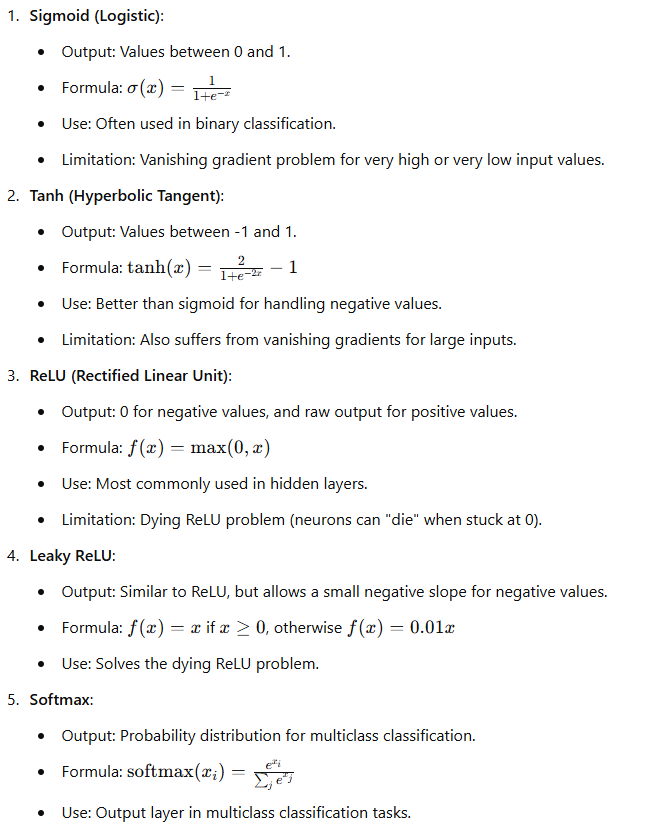

## Z-score

$$
\begin{flalign*}
Z = \frac{X - \mu}{\sigma}
\end{flalign*}
$$

How many standard deviations away from the mean

## Normalization is the process of rescaling numerical features to a common scale, usually in the range 
 
✅ Use When:
You need all features on the same scale (e.g., for distance-based models like KNN or clustering).

Your data doesn’t follow a normal distribution.

🧠 Key Point:
Normalization preserves the shape of the distribution but rescales the values.

In [ ]:
from scipy import stats
import numpy as np

# Example data
data = np.array([10, 20, 30, 40, 50])

# Compute Z-scores
z_scores = stats.zscore(data)

print(z_scores)

# EDA (Exploratory Data Analysis)
EDA is the process of summarizing, visualizing, and understanding your dataset to uncover relationships, detect outliers, and prepare for modeling.

In [ ]:
# 📊 Reusable EDA Template for Jupyter Notebook

# ✅ Step 1: Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Optional AutoEDA Tools
# !pip install pandas-profiling sweetviz dtale

# Set Seaborn style
sns.set(style="whitegrid")

# ✅ Step 2: Load Dataset
df = pd.read_csv("your_dataset.csv")  # Change path to your dataset

# ✅ Step 3: Basic Info
print("\n🔹 Shape:", df.shape)
print("\n🔹 Columns:", df.columns.tolist())
df.info()

# ✅ Step 4: Summary Statistics
print("\n🔹 Summary Statistics:")
display(df.describe(include='all'))

# ✅ Step 5: Missing Values
print("\n🔹 Missing Values:")
display(df.isnull().sum())
msno.matrix(df)
plt.show()

# ✅ Step 6: Data Types & Unique Values
print("\n🔹 Data Types:")
display(df.dtypes)
print("\n🔹 Unique Values Per Column:")
display(df.nunique())

# ✅ Step 7: Value Counts for Categorical Columns
print("\n🔹 Categorical Value Counts:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))

# ✅ Step 8: Visualizations

# Histograms for numeric columns
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram of Numeric Features")
plt.show()

# Boxplots for outliers
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ✅ Step 9: Pairplot (optional - can be slow on big data)
# sns.pairplot(df.select_dtypes(include=np.number).sample(200))
# plt.show()

# ✅ Step 10: Save Cleaned Version (optional)
# df.to_csv("cleaned_dataset.csv", index=False)

print("\n✅ EDA Complete")

## PDF, CDF, PPF
PDF (Probability Density Function): Botton left, it shows that when we select a random data, the probability it will be in the y-axis is.

CDF (Cumulative Distribution Function): Top left, it cumulate all the posibilities from the min 0 to max at 1, so when we select a x value, we will know how much probabilities from the min to it, and we can also calculate the probabilies in a specific range.

PPF (Percent-Point Function): This is the inverse of the CDF. Opposite from CDF, we can use PPF with a given percent of cumulative probabilies to know where the value likely be.

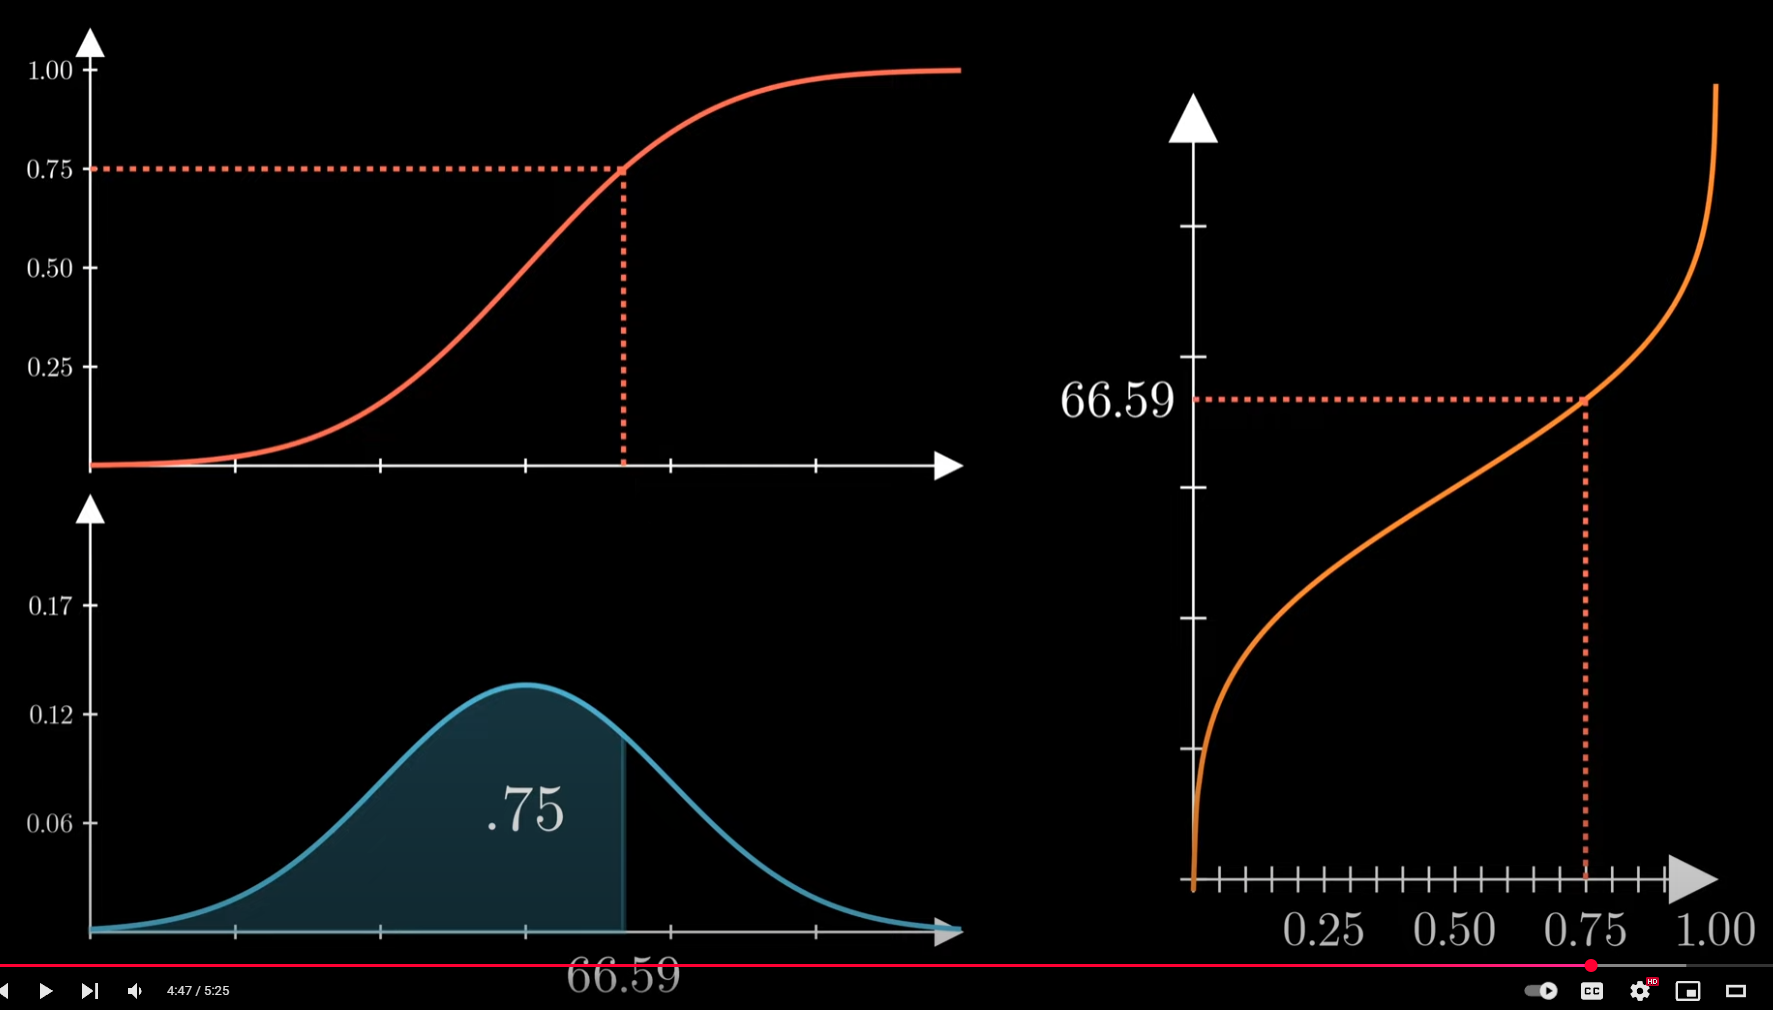

### Q-Q plot
Q-Q Plot (Quantile-Quantile Plot): A Q-Q plot is a graphical tool to compare the distributions of two datasets by plotting their quantiles against each other. If the points fall roughly along a straight line, the distributions are similar. It is commonly used to check if a dataset follows a theoretical distribution, such as the normal distribution.

## Data Leakage 
- Data leakage occurs when information from outside the training dataset — especially data that won’t be available at prediction time — is accidentally used to train the model.

**Here are common causes of data leakage:**
- Using target in feature creation (e.g., target mean encoding)
- Including future data
- Improper data splitting (e.g., before preprocessing)
- Data leakage through identifiers (e.g., IDs correlate with target)
- Duplicated rows across train/test
- Timestamp misuse
- Overlapping user/session data
- Target present in text/description fields